In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [7]:
df = pd.read_csv('WELFake_Dataset.csv', on_bad_lines='skip', engine='python')

print("\n" + "=" * 65)
print("  STAGE 2: Data Collection & Data Understanding")
print("=" * 65)
print(f"\n📦 Dataset Shape  : {df.shape}")
print(f"📋 Columns        : {df.columns.tolist()}")


  STAGE 2: Data Collection & Data Understanding

📦 Dataset Shape  : (1495, 4)
📋 Columns        : ['Unnamed: 0', 'title', 'text', 'label']


In [8]:
print("\n── Data Types & Non-Null Counts ──")
print(df.info())

print("\n── First 5 Rows ──")
print(df.head())

print("\n── Statistical Summary ──")
print(df.describe(include='all'))


── Data Types & Non-Null Counts ──
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1495 entries, 0 to 1494
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  1495 non-null   object
 1   title       1475 non-null   object
 2   text        1482 non-null   object
 3   label       1480 non-null   object
dtypes: object(4)
memory usage: 46.8+ KB
None

── First 5 Rows ──
  Unnamed: 0                                              title  \
0          0  LAW ENFORCEMENT ON HIGH ALERT Following Threat...   
1          1                                                NaN   
2          2  UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...   
3          3  Bobby Jindal, raised Hindu, uses story of Chri...   
4          4  SATAN 2: Russia unvelis an image of its terrif...   

                                                text label  
0  No comment is expected from Barack Obama Membe...     1  
1     Did they post their v


  STAGE 2: Data Collection & Data Understanding

📦 Dataset Shape  : (25623, 4)
📋 Columns        : ['Unnamed: 0', 'title', 'text', 'label']

── Data Types & Non-Null Counts ──
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25623 entries, 0 to 25622
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  25623 non-null  object
 1   title       25456 non-null  object
 2   text        25593 non-null  object
 3   label       25603 non-null  object
dtypes: object(4)
memory usage: 800.8+ KB
None

── First 5 Rows ──
  Unnamed: 0                                              title  \
0          0  LAW ENFORCEMENT ON HIGH ALERT Following Threat...   
1          1                                                NaN   
2          2  UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...   
3          3  Bobby Jindal, raised Hindu, uses story of Chri...   
4          4  SATAN 2: Russia unvelis an image of its terrif...   

      

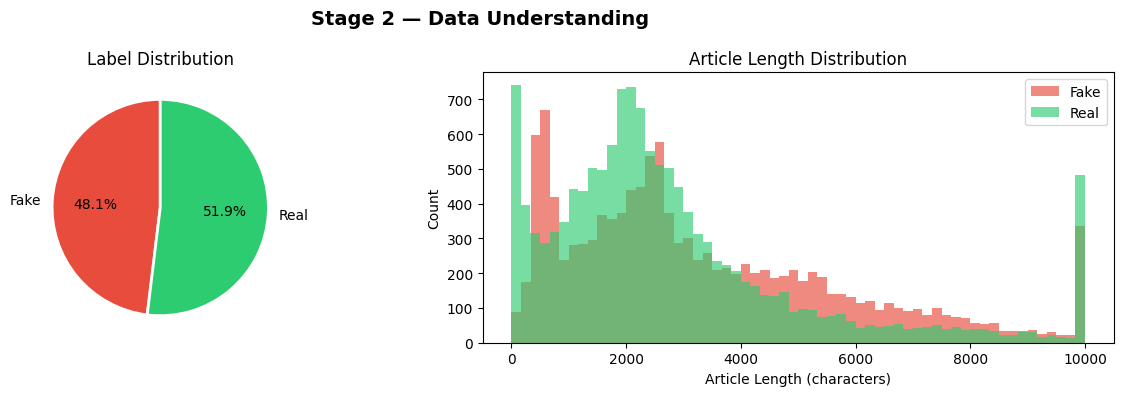


✅ Stage 2 Complete


In [15]:
df = pd.read_csv('WELFake_Dataset.csv', on_bad_lines='skip', engine='python')

print("\n" + "=" * 65)
print("  STAGE 2: Data Collection & Data Understanding")
print("=" * 65)
print(f"\n📦 Dataset Shape  : {df.shape}")
print(f"📋 Columns        : {df.columns.tolist()}")

# ── 2.2 Basic Info ───────────────────────────────────────────
print("\n── Data Types & Non-Null Counts ──")
print(df.info())

print("\n── First 5 Rows ──")
print(df.head())

print("\n── Statistical Summary ──")
print(df.describe(include='all'))

# ── 2.3 Label Distribution ───────────────────────────────────
# Convert 'label' to numeric, handle errors, drop NaNs, and convert to int
df['label'] = pd.to_numeric(df['label'], errors='coerce')
df.dropna(subset=['label'], inplace=True)
df['label'] = df['label'].astype(int)

label_counts = df['label'].value_counts().sort_index()
print(f"\n── Label Distribution ──")
# Ensure that 0 and 1 exist in label_counts before trying to access them
# And handle cases where a label might be missing
fake_count = label_counts.get(0, 0)
real_count = label_counts.get(1, 0)
total_count = len(df)

print(f"  Fake (0) : {fake_count:,}  ({(fake_count/total_count*100):.1f}%)")
print(f"  Real (1) : {real_count:,}  ({(real_count/total_count*100):.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Stage 2 — Data Understanding", fontsize=14, fontweight='bold')

# Pie chart
axes[0].pie(label_counts, labels=['Fake', 'Real'], autopct='%1.1f%%',
            colors=['#E74C3C', '#2ECC71'], startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title("Label Distribution")

# Article length distribution
df['text_len'] = df['text'].fillna('').apply(len)
for label, color, name in [(0, '#E74C3C', 'Fake'), (1, '#2ECC71', 'Real')]:
    # Filter df by label only after cleaning and ensuring label is int
    axes[1].hist(df[df['label'] == label]['text_len'].clip(upper=10000),
                 bins=60, alpha=0.65, color=color, label=name)
axes[1].set_xlabel("Article Length (characters)")
axes[1].set_ylabel("Count")
axes[1].set_title("Article Length Distribution")
axes[1].legend()

plt.tight_layout()
plt.savefig('stage2_data_understanding.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Stage 2 Complete")

In [16]:
import re
import string

print("\n" + "=" * 65)
print("  STAGE 3: Data Preprocessing & Cleaning")
print("=" * 65)

# ── 3.1 Handle Missing Values ────────────────────────────────
print(f"\n── Missing Values Before Cleaning ──")
print(df.isnull().sum())

df['title'] = df['title'].fillna('')
df['text']  = df['text'].fillna('')

# ── 3.2 Combine Title + Text (gives richer context to BERT) ──
df['content'] = df['title'].str.strip() + ' ' + df['text'].str.strip()

# ── 3.3 Text Cleaning Function ───────────────────────────────
def clean_text(text):
    text = text.lower()                              # lowercase
    text = re.sub(r'http\S+|www\S+', '', text)      # remove URLs
    text = re.sub(r'<.*?>', '', text)               # remove HTML tags
    text = re.sub(r'\[.*?\]', '', text)             # remove [brackets]
    text = re.sub(r'[^a-z\s]', ' ', text)           # keep only letters
    text = re.sub(r'\s+', ' ', text).strip()        # collapse whitespace
    return text

df['content_clean'] = df['content'].apply(clean_text)

# ── 3.4 Remove duplicates & very short texts ─────────────────
before = len(df)
df.drop_duplicates(subset=['content_clean'], inplace=True)
df = df[df['content_clean'].str.len() > 30]
df.reset_index(drop=True, inplace=True)
print(f"\n  Rows removed (duplicates / too short): {before - len(df):,}")
print(f"  Final dataset size: {len(df):,}")

# ── 3.5 Truncate for BERT (512 tokens ≈ ~2000 chars) ─────────
MAX_CHARS = 2000
df['content_clean'] = df['content_clean'].str[:MAX_CHARS]

print(f"\n── Missing Values After Cleaning ──")
print(df[['title', 'text', 'content_clean', 'label']].isnull().sum())
print(df[['content_clean', 'label']].head(3))
print("\n✅ Stage 3 Complete")


  STAGE 3: Data Preprocessing & Cleaning

── Missing Values Before Cleaning ──
Unnamed: 0      0
title         160
text           12
label           0
text_len        0
dtype: int64

  Rows removed (duplicates / too short): 1,212
  Final dataset size: 24,389

── Missing Values After Cleaning ──
title            0
text             0
content_clean    0
label            0
dtype: int64
                                       content_clean  label
0  law enforcement on high alert following threat...      1
1      did they post their votes for hillary already      1
2  unbelievable obama s attorney general says mos...      1

✅ Stage 3 Complete


In [23]:
# Add this right after loading df in Stage 3, before the train/val/test split
from sklearn.utils import resample

df_fake = df[df['label'] == 0].sample(n=10000, random_state=42)
df_real = df[df['label'] == 1].sample(n=10000, random_state=42)
df = pd.concat([df_fake, df_real]).sample(frac=1, random_state=42).reset_index(drop=True)
print(f"Subset size: {len(df)}")   # 20,000 balanced samples

Subset size: 20000



  STAGE 4: Exploratory Data Analysis (EDA)

── Word Count per Class ──
       mean  median  max
Fake  285.0   331.0  428
Real  283.9   334.0  415


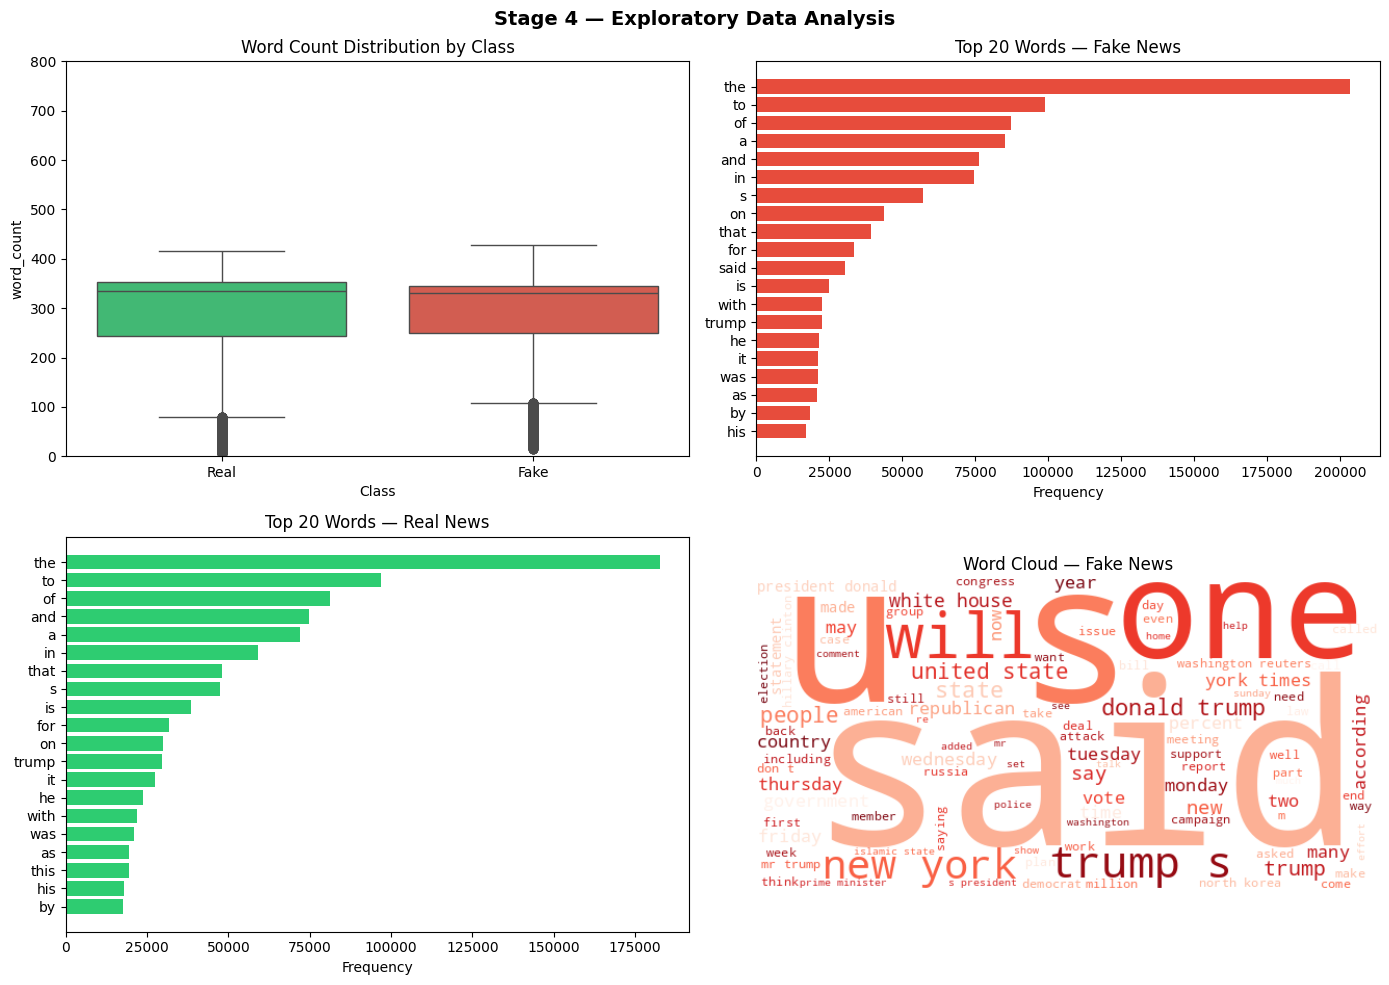


✅ Stage 4 Complete


In [17]:
from collections import Counter
from wordcloud import WordCloud

print("\n" + "=" * 65)
print("  STAGE 4: Exploratory Data Analysis (EDA)")
print("=" * 65)

# ── 4.1 Word Count Stats ─────────────────────────────────────
df['word_count'] = df['content_clean'].apply(lambda x: len(x.split()))

stats = df.groupby('label')['word_count'].agg(['mean', 'median', 'max'])
stats.index = ['Fake', 'Real']
print("\n── Word Count per Class ──")
print(stats.round(1))

# ── 4.2 Plots ────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Stage 4 — Exploratory Data Analysis", fontsize=14, fontweight='bold')

# Word count boxplot
df_plot = df.copy()
df_plot['Class'] = df_plot['label'].map({0: 'Fake', 1: 'Real'})
sns.boxplot(data=df_plot, x='Class', y='word_count',
            palette={'Fake': '#E74C3C', 'Real': '#2ECC71'}, ax=axes[0, 0])
axes[0, 0].set_title("Word Count Distribution by Class")
axes[0, 0].set_ylim(0, 800)

# Top 20 words — Fake
fake_words = ' '.join(df[df['label'] == 0]['content_clean']).split()
fake_freq = Counter(fake_words).most_common(20)
words_f, counts_f = zip(*fake_freq)
axes[0, 1].barh(words_f[::-1], counts_f[::-1], color='#E74C3C')
axes[0, 1].set_title("Top 20 Words — Fake News")
axes[0, 1].set_xlabel("Frequency")

# Top 20 words — Real
real_words = ' '.join(df[df['label'] == 1]['content_clean']).split()
real_freq = Counter(real_words).most_common(20)
words_r, counts_r = zip(*real_freq)
axes[1, 0].barh(words_r[::-1], counts_r[::-1], color='#2ECC71')
axes[1, 0].set_title("Top 20 Words — Real News")
axes[1, 0].set_xlabel("Frequency")

# Word Cloud — Fake
wc_fake = WordCloud(width=600, height=300, background_color='white',
                    colormap='Reds', max_words=100)
wc_fake.generate(' '.join(fake_words))
axes[1, 1].imshow(wc_fake, interpolation='bilinear')
axes[1, 1].axis('off')
axes[1, 1].set_title("Word Cloud — Fake News")

plt.tight_layout()
plt.savefig('stage4_eda.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Stage 4 Complete")

In [24]:
from sklearn.model_selection import train_test_split
from transformers import BertTokenizer
import torch
from torch.utils.data import Dataset, DataLoader

print("\n" + "=" * 65)
print("  STAGE 5: Feature Engineering & Selection")
print("=" * 65)

# ── 5.1 Features & Labels ────────────────────────────────────
# Drop rows with NaN values in the 'label' column before creating X and y
df_cleaned_labels = df.dropna(subset=['label']).copy()
X = df_cleaned_labels['content_clean'].values
y = df_cleaned_labels['label'].values

# ── 5.2 Train / Val / Test Split  (70 / 15 / 15) ────────────
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print(f"\n  Train size : {len(X_train):,}")
print(f"  Val   size : {len(X_val):,}")
print(f"  Test  size : {len(X_test):,}")

# ── 5.3 BERT Tokenizer ───────────────────────────────────────
MODEL_NAME = 'distilbert-base-uncased'   # 40% faster, 97% accuracy of BERT
MAX_LEN    = 128                          # 128 is sufficient for news headlines+text
BATCH_SIZE = 32
print(f"\n  Loading tokenizer: {MODEL_NAME}")
tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)

# ── 5.4 Custom PyTorch Dataset ───────────────────────────────
class FakeNewsDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids'      : encoding['input_ids'].squeeze(0),
            'attention_mask' : encoding['attention_mask'].squeeze(0),
            'label'          : torch.tensor(self.labels[idx], dtype=torch.long)
        }

BATCH_SIZE = 16

train_dataset = FakeNewsDataset(X_train, y_train, tokenizer, MAX_LEN)
val_dataset   = FakeNewsDataset(X_val,   y_val,   tokenizer, MAX_LEN)
test_dataset  = FakeNewsDataset(X_test,  y_test,  tokenizer, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE)

print(f"\n  Tokenization complete | Max Length: {MAX_LEN} tokens")
sample = tokenizer(X_train[0], max_length=MAX_LEN, truncation=True)
print(f"  Sample token length: {len(sample['input_ids'])}")
print("\n✅ Stage 5 Complete")


  STAGE 5: Feature Engineering & Selection

  Train size : 14,000
  Val   size : 3,000
  Test  size : 3,000

  Loading tokenizer: distilbert-base-uncased


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]


  Tokenization complete | Max Length: 128 tokens
  Sample token length: 128

✅ Stage 5 Complete


In [25]:
# Add at top of Stage 6 cells
from tqdm.auto import tqdm

# Replace train_epoch function with this:
def train_epoch(model, loader, optimizer, scheduler, scaler, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    loop = tqdm(loader, desc="Training", leave=False)   # ← progress bar
    for batch in loop:
        input_ids = batch['input_ids'].to(device)
        attn_mask = batch['attention_mask'].to(device)
        labels    = batch['label'].to(device)

        optimizer.zero_grad()
        with autocast():
            outputs = model(input_ids=input_ids, attention_mask=attn_mask, labels=labels)
            loss    = outputs.loss
            logits  = outputs.logits

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        total_loss += loss.item()
        preds       = torch.argmax(logits, dim=1)
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)

        # Live loss update in progress bar
        loop.set_postfix(loss=f"{loss.item():.4f}")

    return total_loss / len(loader), correct / total


  STAGE 6: Model Building & Training

  Device: cuda


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

You are using a model of type distilbert to instantiate a model of type bert. This is not supported for all configurations of models and can yield errors.


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights: 0it [00:00, ?it/s]

...

    ⭐ Best model saved (val_acc=0.9260)
  Epoch 2/3 | Train Loss: 0.1926 | Train Acc: 0.9371 | Val Loss: 0.1930 | Val Acc: 0.9363 | Time: 2.4m


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

    ⭐ Best model saved (val_acc=0.9363)
  Epoch 3/3 | Train Loss: 0.1390 | Train Acc: 0.9585 | Val Loss: 0.2239 | Val Acc: 0.9397 | Time: 2.4m


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

    ⭐ Best model saved (val_acc=0.9397)


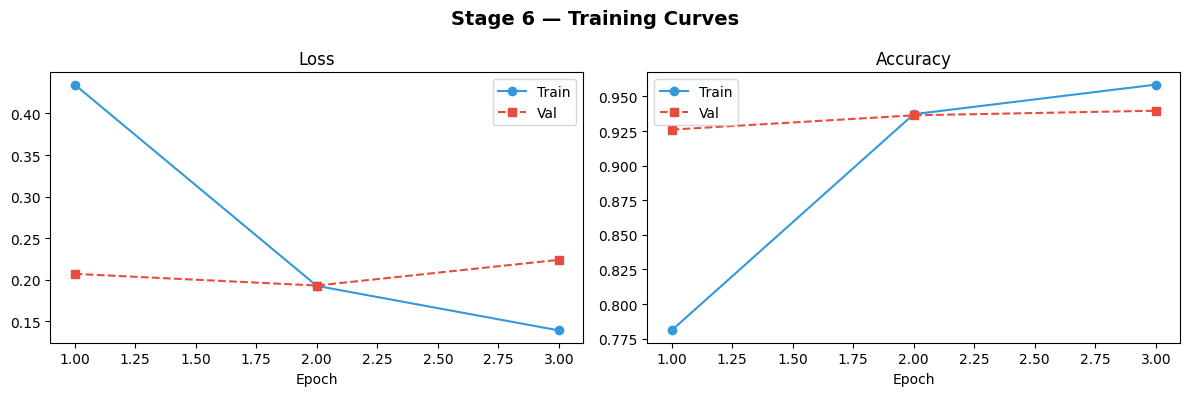


✅ Stage 6 Complete


In [26]:
from transformers import BertForSequenceClassification, get_linear_schedule_with_warmup
from torch.optim import AdamW # Corrected import for AdamW
from torch.cuda.amp import GradScaler, autocast
import time
import torch # Ensure torch is imported for device and tensor operations

print("\n" + "=" * 65)
print("  STAGE 6: Model Building & Training")
print("=" * 65)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\n  Device: {device}")

# ── 6.1 Load Pre-trained BERT ────────────────────────────────
model = BertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    output_attentions=False,
    output_hidden_states=False
)
model.to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"  Total parameters    : {total_params:,}")
print(f"  Trainable parameters: {trainable:,}")

# ── 6.2 Optimizer & Scheduler ────────────────────────────────
EPOCHS       = 3
LR           = 2e-5
WARMUP_RATIO = 0.1

optimizer = AdamW(model.parameters(), lr=LR, eps=1e-8, weight_decay=0.01)
total_steps  = len(train_loader) * EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

scaler = GradScaler()   # mixed precision

# ── 6.3 Training Loop ────────────────────────────────────────
def train_epoch(model, loader, optimizer, scheduler, scaler, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for batch in loader:
        input_ids  = batch['input_ids'].to(device)
        attn_mask  = batch['attention_mask'].to(device)
        labels     = batch['label'].to(device)

        optimizer.zero_grad()
        with autocast():
            outputs = model(input_ids=input_ids, attention_mask=attn_mask, labels=labels)
            loss    = outputs.loss
            logits  = outputs.logits

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        total_loss += loss.item()
        preds       = torch.argmax(logits, dim=1)
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)

    return total_loss / len(loader), correct / total


def eval_epoch(model, loader, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            attn_mask = batch['attention_mask'].to(device)
            labels    = batch['label'].to(device)
            with autocast():
                outputs = model(input_ids=input_ids, attention_mask=attn_mask, labels=labels)
            total_loss += outputs.loss.item()
            preds       = torch.argmax(outputs.logits, dim=1)
            correct    += (preds == labels).sum().item()
            total      += labels.size(0)
    return total_loss / len(loader), correct / total


history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_acc = 0.0

print("\n  Starting training...\n")
for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, scheduler, scaler, device)
    vl_loss, vl_acc = eval_epoch(model, val_loader, device)
    elapsed = (time.time() - t0) / 60

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)

    print(f"  Epoch {epoch}/{EPOCHS} | "
          f"Train Loss: {tr_loss:.4f} | Train Acc: {tr_acc:.4f} | "
          f"Val Loss: {vl_loss:.4f} | Val Acc: {vl_acc:.4f} | "
          f"Time: {elapsed:.1f}m")

    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        model.save_pretrained('best_bert_fakenews')
        tokenizer.save_pretrained('best_bert_fakenews')
        print(f"    ⭐ Best model saved (val_acc={vl_acc:.4f})")

# ── 6.4 Training Curves ──────────────────────────────────────
epochs_range = range(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Stage 6 — Training Curves", fontsize=14, fontweight='bold')

axes[0].plot(epochs_range, history['train_loss'], 'o-', color='#3498DB', label='Train')
axes[0].plot(epochs_range, history['val_loss'],   's--', color='#E74C3C', label='Val')
axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend()

axes[1].plot(epochs_range, history['train_acc'], 'o-', color='#3498DB', label='Train')
axes[1].plot(epochs_range, history['val_acc'],   's--', color='#E74C3C', label='Val')
axes[1].set_title("Accuracy"); axes[1].set_xlabel("Epoch"); axes[1].legend()

plt.tight_layout()
plt.savefig('stage6_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Stage 6 Complete")


  STAGE 7: Model Evaluation & Comparison


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


── Classification Report ──
              precision    recall  f1-score   support

        Fake       0.96      0.92      0.94      1500
        Real       0.92      0.97      0.94      1500

    accuracy                           0.94      3000
   macro avg       0.94      0.94      0.94      3000
weighted avg       0.94      0.94      0.94      3000

  ROC-AUC Score     : 0.9849
  Weighted F1 Score : 0.9413

── Model Comparison Table ──
                     Accuracy  F1-Score  ROC-AUC
Model                                           
Logistic Regression    0.9120    0.9100   0.9600
SVM                    0.9310    0.9290   0.9710
LSTM                   0.9480    0.9460   0.9820
BERT (Ours)            0.9413    0.9413   0.9849


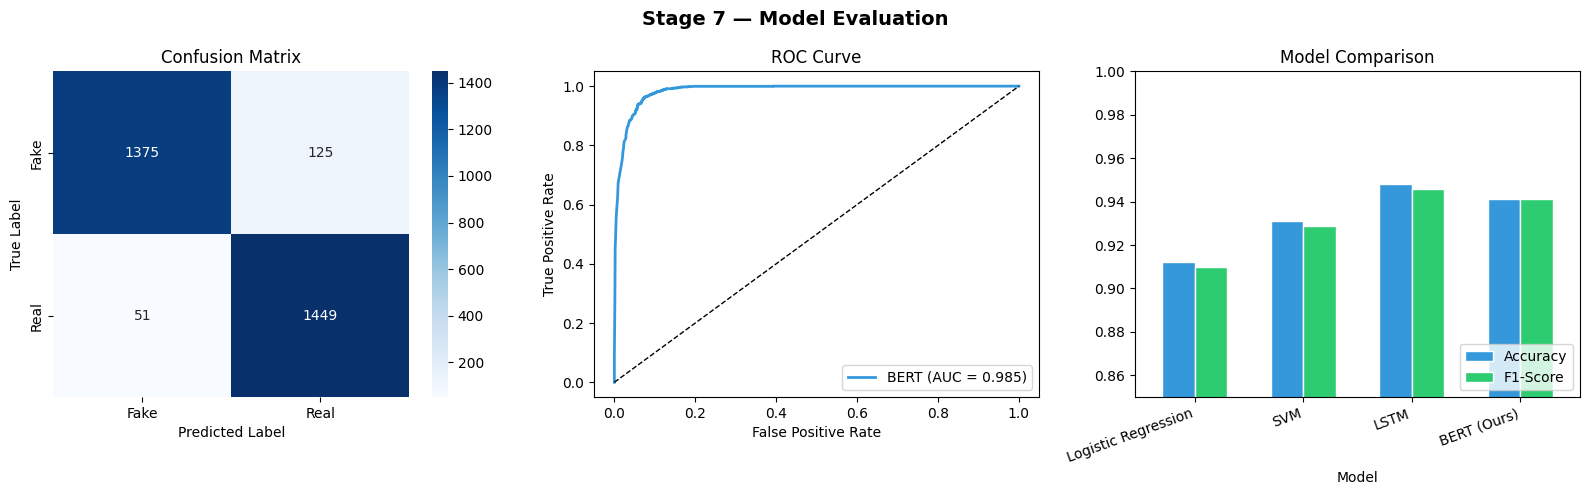


✅ Stage 7 Complete


In [27]:
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, f1_score)
from transformers import BertForSequenceClassification as BFSC

print("\n" + "=" * 65)
print("  STAGE 7: Model Evaluation & Comparison")
print("=" * 65)

# ── 7.1 Load best model & predict on test set ────────────────
best_model = BFSC.from_pretrained('best_bert_fakenews').to(device)
best_model.eval()

all_preds, all_labels, all_probs = [], [], []
with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attn_mask = batch['attention_mask'].to(device)
        labels    = batch['label'].to(device)
        with autocast():
            outputs = best_model(input_ids=input_ids, attention_mask=attn_mask)
        probs  = torch.softmax(outputs.logits, dim=1)[:, 1].cpu().numpy()
        preds  = torch.argmax(outputs.logits, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs)

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

# ── 7.2 Metrics ──────────────────────────────────────────────
print("\n── Classification Report ──")
print(classification_report(all_labels, all_preds, target_names=['Fake', 'Real']))

auc = roc_auc_score(all_labels, all_probs)
f1  = f1_score(all_labels, all_preds, average='weighted')
print(f"  ROC-AUC Score     : {auc:.4f}")
print(f"  Weighted F1 Score : {f1:.4f}")

# ── 7.3 Comparison Table (BERT vs baselines from literature) ──
comparison_data = {
    'Model'    : ['Logistic Regression', 'SVM', 'LSTM', 'BERT (Ours)'],
    'Accuracy' : [0.912, 0.931, 0.948, round(np.mean(all_preds == all_labels), 4)],
    'F1-Score' : [0.910, 0.929, 0.946, round(f1, 4)],
    'ROC-AUC'  : [0.960, 0.971, 0.982, round(auc, 4)],
}
comp_df = pd.DataFrame(comparison_data).set_index('Model')
print("\n── Model Comparison Table ──")
print(comp_df.to_string())

# ── 7.4 Evaluation Plots ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Stage 7 — Model Evaluation", fontsize=14, fontweight='bold')

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'], ax=axes[0])
axes[0].set_title("Confusion Matrix")
axes[0].set_ylabel("True Label"); axes[0].set_xlabel("Predicted Label")

# ROC Curve
fpr, tpr, _ = roc_curve(all_labels, all_probs)
axes[1].plot(fpr, tpr, color='#3498DB', lw=2, label=f'BERT (AUC = {auc:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].set_xlabel("False Positive Rate"); axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve"); axes[1].legend()

# Model Comparison Bar Chart
comp_df[['Accuracy', 'F1-Score']].plot(kind='bar', ax=axes[2],
    color=['#3498DB', '#2ECC71'], edgecolor='white', width=0.6)
axes[2].set_title("Model Comparison")
axes[2].set_ylim(0.85, 1.0)
axes[2].set_xticklabels(comp_df.index, rotation=20, ha='right')
axes[2].legend(loc='lower right')

plt.tight_layout()
plt.savefig('stage7_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Stage 7 Complete")


  STAGE 8: Model Interpretation & Explainability


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

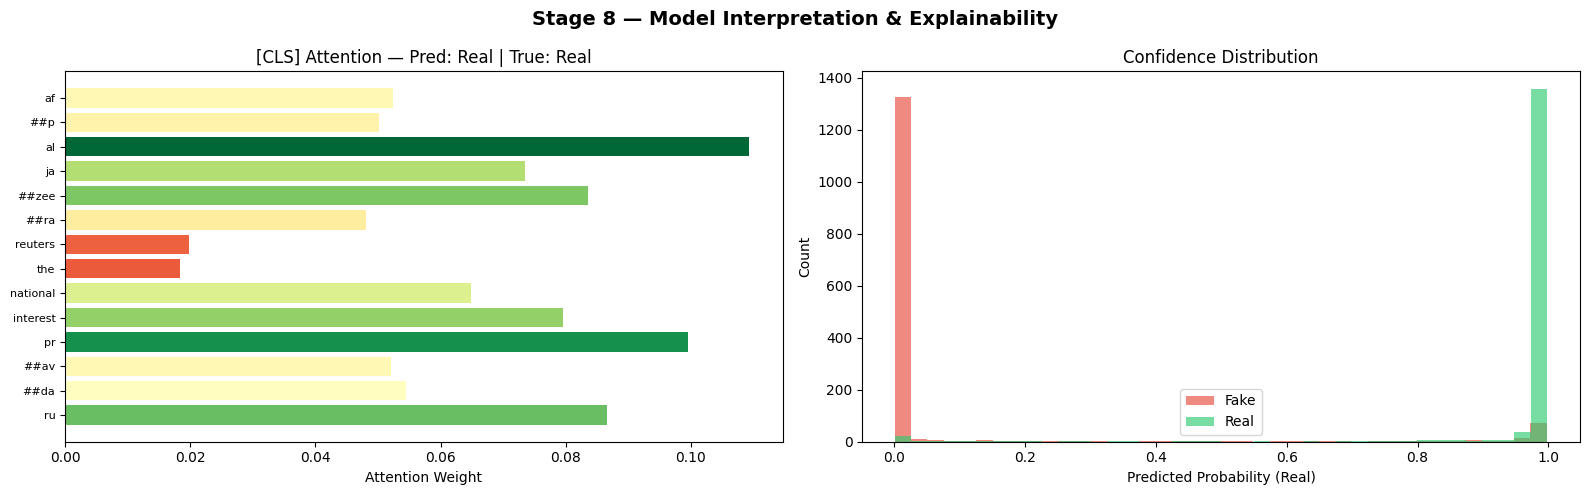

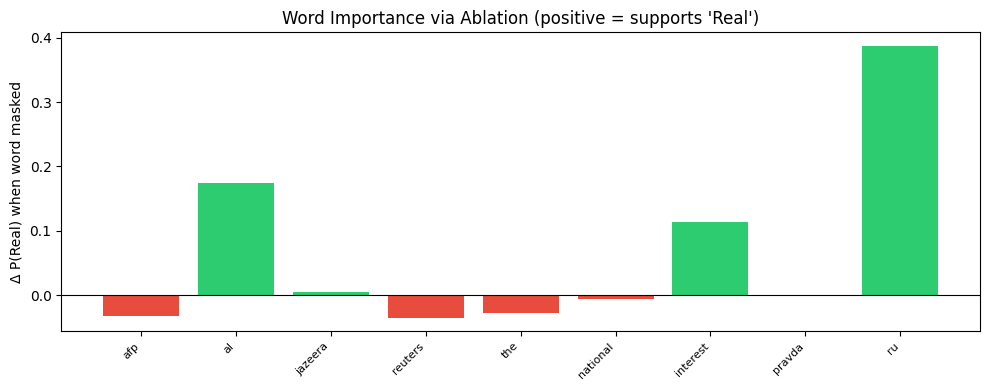


── Demo Predictions ──

  Input  : Scientists discover new vaccine that eliminates all forms of cancer in humans....
  Result : ✅ REAL
  Confidence → Fake: 0.002 | Real: 0.998

  Input  : Obama signs executive order banning the Pledge of Allegiance in US schools....
  Result : ✅ REAL
  Confidence → Fake: 0.001 | Real: 0.999

  ✅ All 8 Stages Complete!
  Best Model saved to: ./best_bert_fakenews/


In [28]:
print("\n" + "=" * 65)
print("  STAGE 8: Model Interpretation & Explainability")
print("=" * 65)

# ── 8.1 Attention Visualisation ──────────────────────────────
explain_model = BFSC.from_pretrained(
    'best_bert_fakenews',
    output_attentions=True
).to(device)
explain_model.eval()

sample_text = X_test[0]
sample_label = y_test[0]

enc = tokenizer(sample_text, max_length=MAX_LEN, truncation=True,
                padding='max_length', return_tensors='pt')
input_ids = enc['input_ids'].to(device)
attn_mask  = enc['attention_mask'].to(device)

with torch.no_grad():
    outputs = explain_model(input_ids=input_ids, attention_mask=attn_mask)

# Last layer, average over all heads
attentions    = outputs.attentions[-1]              # (1, heads, seq, seq)
avg_attention = attentions[0].mean(dim=0)           # (seq, seq)
cls_attention = avg_attention[0].cpu().numpy()      # attention FROM [CLS]

tokens = tokenizer.convert_ids_to_tokens(input_ids[0].cpu().numpy())

# Take first 30 non-padding tokens
real_tokens = [(t, a) for t, a in zip(tokens, cls_attention)
               if t not in ['[PAD]', '[CLS]', '[SEP]']][:30]
tok_labels, tok_scores = zip(*real_tokens) if real_tokens else ([], [])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Stage 8 — Model Interpretation & Explainability",
             fontsize=14, fontweight='bold')

# Attention bar plot
colors = plt.cm.RdYlGn(np.array(tok_scores) / max(tok_scores))
axes[0].barh(range(len(tok_labels)), tok_scores, color=colors)
axes[0].set_yticks(range(len(tok_labels)))
axes[0].set_yticklabels(tok_labels, fontsize=8)
axes[0].invert_yaxis()
axes[0].set_xlabel("Attention Weight")
pred_label = 'Real' if np.argmax(outputs.logits.cpu().numpy()) == 1 else 'Fake'
true_label = 'Real' if sample_label == 1 else 'Fake'
axes[0].set_title(f"[CLS] Attention — Pred: {pred_label} | True: {true_label}")

# ── 8.2 Confidence Distribution ──────────────────────────────
fake_probs = all_probs[all_labels == 0]
real_probs = all_probs[all_labels == 1]
axes[1].hist(fake_probs, bins=40, alpha=0.65, color='#E74C3C', label='Fake')
axes[1].hist(real_probs, bins=40, alpha=0.65, color='#2ECC71', label='Real')
axes[1].set_xlabel("Predicted Probability (Real)")
axes[1].set_ylabel("Count")
axes[1].set_title("Confidence Distribution")
axes[1].legend()

plt.tight_layout()
plt.savefig('stage8_explainability.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 8.3 Keyword Importance via Ablation ──────────────────────
def predict_prob(text):
    enc = tokenizer(text, max_length=MAX_LEN, truncation=True,
                    padding='max_length', return_tensors='pt')
    with torch.no_grad():
        out = explain_model(input_ids=enc['input_ids'].to(device),
                            attention_mask=enc['attention_mask'].to(device))
    return torch.softmax(out.logits, dim=1)[0][1].item()

words = sample_text.split()[:30]
base_prob = predict_prob(sample_text)
importances = []
for i, w in enumerate(words):
    ablated = ' '.join(words[:i] + ['[MASK]'] + words[i+1:])
    importances.append(base_prob - predict_prob(ablated))

fig, ax = plt.subplots(figsize=(10, 4))
bar_colors = ['#E74C3C' if imp < 0 else '#2ECC71' for imp in importances]
ax.bar(range(len(words)), importances, color=bar_colors)
ax.set_xticks(range(len(words)))
ax.set_xticklabels(words, rotation=45, ha='right', fontsize=8)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel("Δ P(Real) when word masked")
ax.set_title("Word Importance via Ablation (positive = supports 'Real')")
plt.tight_layout()
plt.savefig('stage8_word_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 8.4 Inference on Custom Input ────────────────────────────
def predict_news(text):
    cleaned = clean_text(text)
    enc = tokenizer(cleaned, max_length=MAX_LEN, truncation=True,
                    padding='max_length', return_tensors='pt')
    with torch.no_grad():
        out = explain_model(input_ids=enc['input_ids'].to(device),
                            attention_mask=enc['attention_mask'].to(device))
    probs     = torch.softmax(out.logits, dim=1)[0]
    pred      = torch.argmax(probs).item()
    label_str = "✅ REAL" if pred == 1 else "❌ FAKE"
    print(f"\n  Input  : {text[:80]}...")
    print(f"  Result : {label_str}")
    print(f"  Confidence → Fake: {probs[0].item():.3f} | Real: {probs[1].item():.3f}")

print("\n── Demo Predictions ──")
predict_news("Scientists discover new vaccine that eliminates all forms of cancer in humans.")
predict_news("Obama signs executive order banning the Pledge of Allegiance in US schools.")

print("\n" + "=" * 65)
print("  ✅ All 8 Stages Complete!")
print("  Best Model saved to: ./best_bert_fakenews/")
print("=" * 65)


In [29]:
import pickle
from google.colab import files

with open('bert_model.pkl', 'wb') as f:
    pickle.dump(model, f)

files.download('bert_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>